# Makine arızası tahmini: AI4I 2020 veri seti

TRAI bootcamp final projem. Google Colab'da yazdım.

Amaç:
- makinelerin sensör verilerinden arıza çıkıp çıkmayacağını tahmin etmek (ikili sınıflandırma)
- lojistik regresyon, karar ağacı, random forest ve xgboost modellerini karşılaştırmak
- dengesiz veri setinde accuracy dışındaki metriklerin (recall, precision, f1) önemini görmek
- öznitelik mühendisliği, stratified k-fold, grid search ve SHAP ile modeli bir adım ileri taşımak

Veri seti:
- AI4I 2020 Predictive Maintenance Dataset
- UCI: https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset
- 10000 satır, 14 sütun, hedef değişken: Machine failure (0: arıza yok, 1: arıza var)
- 10000 satırın sadece 339 tanesi arıza, yani veri seti dengesiz

Plan/Program:
1. veri setinin yüklenmesi ve incelenmesi
2. eksik veri kontrolü
3. keşifsel veri analizi (hedef dağılımı, boxplot, korelasyon)
4. veri hazırlama (sütun çıkarma, one-hot encoding, standardizasyon)
5. eğitim ve test veri setlerinin oluşturulması
6. modellerin eğitilmesi ve değerlendirilmesi
7. class_weight="balanced" denemesi
8. random forest feature importance incelemesi
9. öznitelik mühendisliği (sicaklik_farki ve guc değişkenleri)
10. stratified k-fold ile çapraz doğrulama
11. grid search ile random forest hiperparametre araması
12. xgboost ve scale_pos_weight denemesi
13. SHAP ile modelin kararlarının açıklanması

In [1]:
%matplotlib inline

# 1. gerekli kütüphanelerin içeriye aktarılması
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, f1_score

from xgboost import XGBClassifier
import shap

# grafikleri kaydedeceğimiz klasör
os.makedirs("grafikler", exist_ok=True)

Veri setini önce Kaggle'da bulmuştum, sonra orijinalinin UCI'daki AI4I 2020 olduğunu görünce onu kullandım. İlk iş, veriye bakmak.

In [2]:
# 2. veri setinin yüklenmesi ve incelenmesi
df = pd.read_csv("ai4i2020.csv")

print(f"Satır ve sütun sayısı: {df.shape}")
df.head()

Satır ve sütun sayısı: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# sütun tipleri ve temel istatistikler
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Eksik veri var mı diye hocanın derste kullandığı kalıpla kontrol ettim.

In [4]:
# 3. eksik veri kontrolü
if df.isna().any().any():
    df.dropna(inplace=True)
    print("nan değerleri veri setinden çıkardık")
else:
    print("nan değer bulunmuyor")

nan değer bulunmuyor


Asıl merak ettiğim hedef değişkenin dağılımıydı, çünkü arıza sayısının az olduğunu veri setinin açıklamasında okumuştum.

Machine failure
0    9661
1     339
Name: count, dtype: int64
Arıza oranı: %3.4


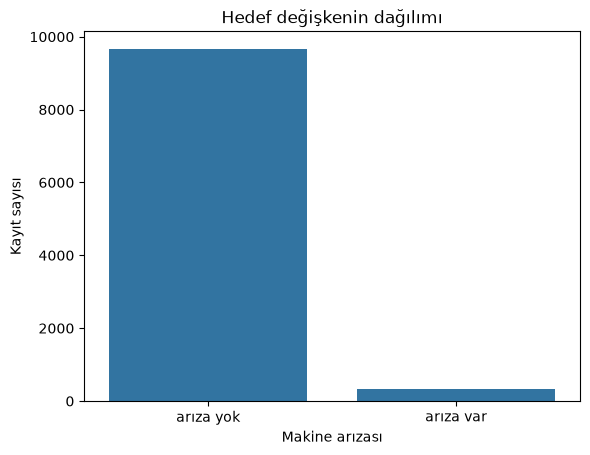

In [5]:
# 4. hedef değişkenin dağılımı
print(df["Machine failure"].value_counts())
print(f"Arıza oranı: %{100 * df['Machine failure'].mean():.1f}")

plt.figure()
sns.countplot(x="Machine failure", data=df)
plt.xticks([0, 1], ["arıza yok", "arıza var"])
plt.xlabel("Makine arızası")
plt.ylabel("Kayıt sayısı")
plt.title("Hedef değişkenin dağılımı")
plt.savefig("grafikler/hedef_degisken_dagilimi.png", dpi=150, bbox_inches="tight")
plt.show()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


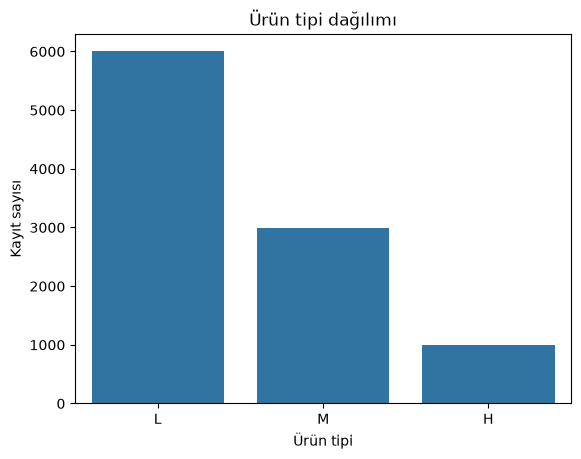

In [6]:
# 5. ürün tipi dağılımı (L: düşük, M: orta, H: yüksek kalite)
print(df["Type"].value_counts())

plt.figure()
sns.countplot(x="Type", data=df, order=["L", "M", "H"])
plt.xlabel("Ürün tipi")
plt.ylabel("Kayıt sayısı")
plt.title("Ürün tipi dağılımı")
plt.savefig("grafikler/urun_tipi_dagilimi.png", dpi=150, bbox_inches="tight")
plt.show()

Sensör değişkenleri arızalı ve arızasız kayıtlarda farklı davranıyor mu diye boxplot çizdim. Tork ve takım aşınmasında fark bariz görünüyor.

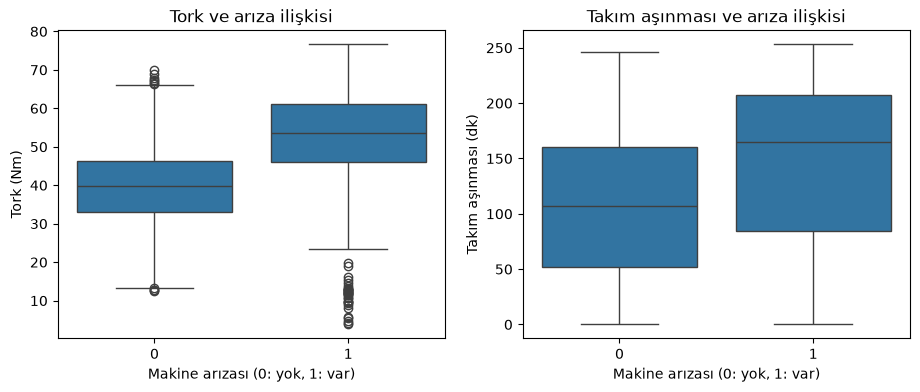

In [7]:
# 6. torque ve tool wear değişkenlerinin arıza kırılımı
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(x="Machine failure", y="Torque [Nm]", data=df, ax=axes[0])
axes[0].set_xlabel("Makine arızası (0: yok, 1: var)")
axes[0].set_ylabel("Tork (Nm)")
axes[0].set_title("Tork ve arıza ilişkisi")

sns.boxplot(x="Machine failure", y="Tool wear [min]", data=df, ax=axes[1])
axes[1].set_xlabel("Makine arızası (0: yok, 1: var)")
axes[1].set_ylabel("Takım aşınması (dk)")
axes[1].set_title("Takım aşınması ve arıza ilişkisi")

plt.savefig("grafikler/tork_ve_takim_asinmasi_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

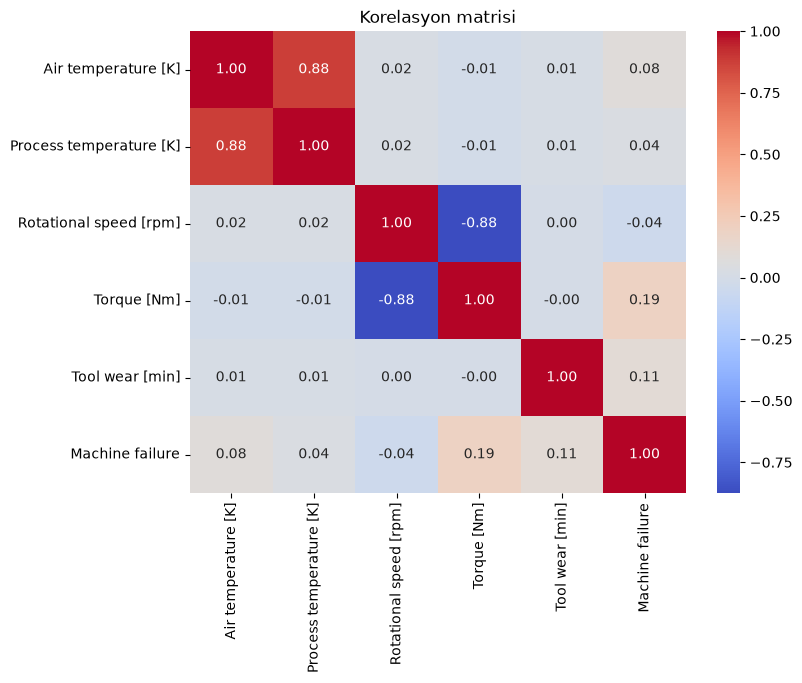

In [8]:
# 7. sayısal değişkenler arasındaki korelasyon
sayisal_sutunlar = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]", "Machine failure"]

korelasyon_matrisi = df[sayisal_sutunlar].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(korelasyon_matrisi, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelasyon matrisi")
plt.savefig("grafikler/korelasyon_matrisi.png", dpi=150, bbox_inches="tight")
plt.show()

Veri hazırlama kısmı. UDI ve Product ID kimlik bilgisi, modele girmemeli. TWF, HDF, PWF, OSF, RNF sütunları ise arızanın alt tipleri. İlk denemede bunları modelde bırakmıştım, skorlar şüpheli derecede iyi çıkınca fark ettim: bu sütunlar cevabı modele baştan söylüyor (veri sızıntısı). Hepsini çıkarıyorum. Type sütununu da one-hot encoding ile sayısala çeviriyorum.

In [9]:
# 8. modele girmeyecek sütunların çıkarılması
# UDI ve Product ID kimlik bilgisi, TWF/HDF/PWF/OSF/RNF ise arıza tipinin alt etiketleri (hedefi sızdırıyor)
df_model = df.drop(["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"], axis=1)

# 9. Type sütununa one-hot encoding
df_model = pd.get_dummies(df_model, columns=["Type"], drop_first=True, dtype=int)

print(df_model.head())

   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  Type_L  Type_M  
0         42.8                0                0       0       1  
1         46.3                3                0       1       0  
2         49.4                5                0       1       0  
3         39.5                7                0       1       0  
4         40.0                9                0       1       0  


In [10]:
# 10. feature ve target değişkenlerin tanımlanması
X = df_model.drop(["Machine failure"], axis=1)
y = df_model["Machine failure"]

ozellik_isimleri = X.columns.tolist()
print(ozellik_isimleri)

# 11. eğitim ve test veri setlerinin oluşturulması
# stratify=y ile arıza oranı iki kümede de aynı kalıyor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']
X_train: (8000, 7)
X_test: (2000, 7)


Lojistik regresyon için değişkenleri StandardScaler ile ölçekledim. Ölçekleyiciyi sadece eğitim verisinde fit etmek gerekiyor, test verisine sadece transform uygulanıyor. Ağaç tabanlı modeller ölçekten etkilenmediği için onlara ham veriyi verdim.

In [11]:
# 12. lojistik regresyon için standardizasyon (ölçekleyici sadece eğitim verisinde fit edilir)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Hocanın supervised learning derslerindeki üç sınıflandırma modelini kurdum.

In [12]:
# 13. modellerin tanımlanması ve eğitilmesi
log_reg = LogisticRegression(max_iter=1000)
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)

log_reg.fit(X_train_scaled, y_train)
tree_clf.fit(X_train, y_train)
random_forest_clf.fit(X_train, y_train)

# 14. test verisi ile tahmin yapılması
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_tree = tree_clf.predict(X_test)
y_pred_forest = random_forest_clf.predict(X_test)

# 15. accuracy ile ilk değerlendirme
print(f"Lojistik regresyon accuracy: {accuracy_score(y_test, y_pred_log)}")
print(f"Karar ağacı accuracy: {accuracy_score(y_test, y_pred_tree)}")
print(f"Random forest accuracy: {accuracy_score(y_test, y_pred_forest)}")

Lojistik regresyon accuracy: 0.9675
Karar ağacı accuracy: 0.973
Random forest accuracy: 0.9815


Üç accuracy de yüksek görünüyor. Ama veri setinin %96.6'sı zaten "arıza yok", yani her şeye "arıza yok" diyen bir model bile %96.6 accuracy alır. Hoca derste dengesiz veri setinde accuracy'ye güvenmeyin demişti. O yüzden classification report ile sınıf bazında recall, precision ve f1 değerlerine bakıyorum.

In [13]:
# 16. classification report ile detaylı değerlendirme
print("Lojistik regresyon:")
print(classification_report(y_test, y_pred_log, target_names=["arıza yok", "arıza var"]))

print("Karar ağacı:")
print(classification_report(y_test, y_pred_tree, target_names=["arıza yok", "arıza var"]))

print("Random forest:")
print(classification_report(y_test, y_pred_forest, target_names=["arıza yok", "arıza var"]))

Lojistik regresyon:
              precision    recall  f1-score   support

   arıza yok       0.97      1.00      0.98      1932
   arıza var       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000

Karar ağacı:
              precision    recall  f1-score   support

   arıza yok       0.98      1.00      0.99      1932
   arıza var       0.77      0.29      0.43        68

    accuracy                           0.97      2000
   macro avg       0.87      0.65      0.71      2000
weighted avg       0.97      0.97      0.97      2000

Random forest:
              precision    recall  f1-score   support

   arıza yok       0.98      1.00      0.99      1932
   arıza var       0.88      0.53      0.66        68

    accuracy                           0.98      2000
   macro avg       0.93      0.76      0.83      2000
weighted avg       0.98   

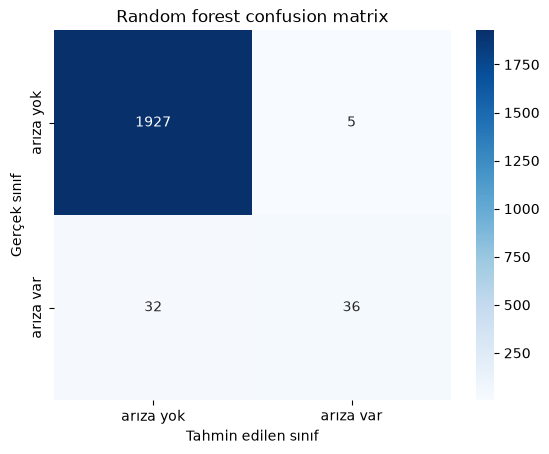

In [14]:
# 17. random forest confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_forest)

plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt="g", cmap="Blues", xticklabels=["arıza yok", "arıza var"], yticklabels=["arıza yok", "arıza var"])
plt.xlabel("Tahmin edilen sınıf")
plt.ylabel("Gerçek sınıf")
plt.title("Random forest confusion matrix")
plt.savefig("grafikler/confusion_matrix_random_forest.png", dpi=150, bbox_inches="tight")
plt.show()

Arıza sınıfındaki recall düşük, yani gerçek arızaların bir kısmını kaçırıyoruz. Üretimde kaçan arıza (false negative) plansız duruş demek, yanlış alarmdan çok daha pahalı. class_weight="balanced" parametresi azınlık sınıfına daha fazla ağırlık veriyor, lojistik regresyon ve random forest ile deniyorum.

In [15]:
# 18. class_weight="balanced" ile lojistik regresyon ve random forest
log_reg_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
forest_balanced = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)

log_reg_balanced.fit(X_train_scaled, y_train)
forest_balanced.fit(X_train, y_train)

y_pred_log_balanced = log_reg_balanced.predict(X_test_scaled)
y_pred_forest_balanced = forest_balanced.predict(X_test)

# 19. arıza sınıfı (1) için recall karşılaştırması
print(f"Lojistik regresyon recall: {recall_score(y_test, y_pred_log)} -> balanced: {recall_score(y_test, y_pred_log_balanced)}")
print(f"Random forest recall: {recall_score(y_test, y_pred_forest)} -> balanced: {recall_score(y_test, y_pred_forest_balanced)}")

print()
print("Dengeli lojistik regresyon:")
print(classification_report(y_test, y_pred_log_balanced, target_names=["arıza yok", "arıza var"]))

Lojistik regresyon recall: 0.10294117647058823 -> balanced: 0.8235294117647058
Random forest recall: 0.5294117647058824 -> balanced: 0.6911764705882353

Dengeli lojistik regresyon:
              precision    recall  f1-score   support

   arıza yok       0.99      0.82      0.90      1932
   arıza var       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



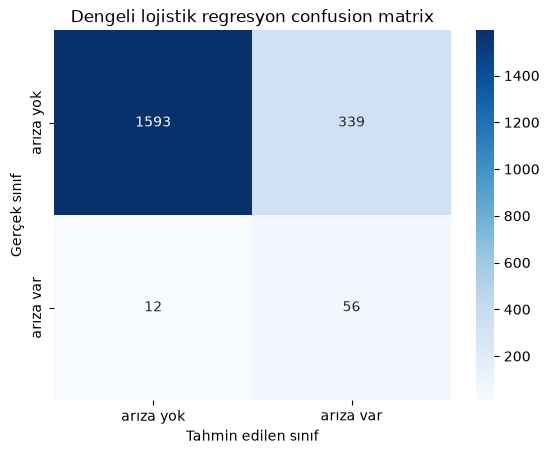

In [16]:
# 20. dengeli lojistik regresyon confusion matrix
conf_matrix_balanced = confusion_matrix(y_test, y_pred_log_balanced)

plt.figure()
sns.heatmap(conf_matrix_balanced, annot=True, fmt="g", cmap="Blues", xticklabels=["arıza yok", "arıza var"], yticklabels=["arıza yok", "arıza var"])
plt.xlabel("Tahmin edilen sınıf")
plt.ylabel("Gerçek sınıf")
plt.title("Dengeli lojistik regresyon confusion matrix")
plt.savefig("grafikler/confusion_matrix_dengeli_lojistik.png", dpi=150, bbox_inches="tight")
plt.show()

Son olarak random forest'a göre hangi değişkenler arızayı en çok haber veriyor diye feature importance değerlerine baktım.

Torque [Nm]: 0.3258021261350634
Rotational speed [rpm]: 0.22744484813382984
Tool wear [min]: 0.17005865139208484
Air temperature [K]: 0.1336961290591712
Process temperature [K]: 0.11656251260559392
Type_L: 0.01637306880446208
Type_M: 0.010062663869794644


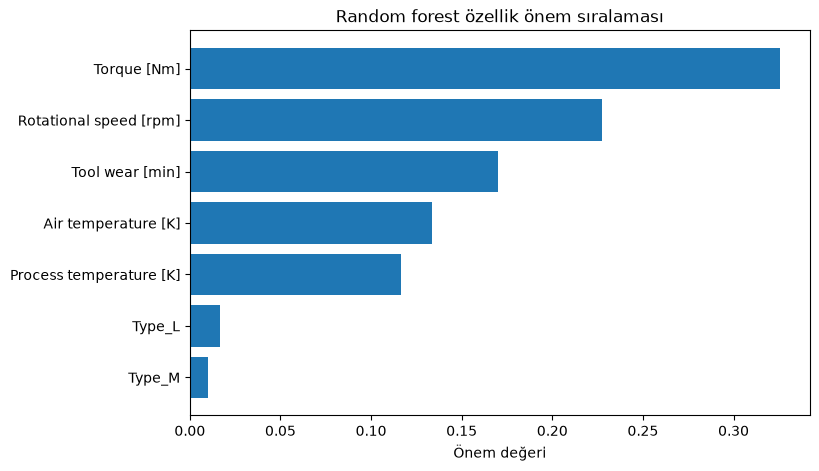

In [17]:
# 21. random forest feature importance
feature_importances = random_forest_clf.feature_importances_

# önem derecelerini büyükten küçüğe sırala
feature_importances_sorted = sorted(zip(feature_importances, ozellik_isimleri), reverse=True)

for importance, feature_name in feature_importances_sorted:
    print(f"{feature_name}: {importance}")

# bar grafik
onem_degerleri = [imp for imp, isim in feature_importances_sorted]
isimler = [isim for imp, isim in feature_importances_sorted]

plt.figure(figsize=(8, 5))
plt.barh(isimler[::-1], onem_degerleri[::-1])
plt.xlabel("Önem değeri")
plt.title("Random forest özellik önem sıralaması")
plt.savefig("grafikler/ozellik_onem_siralamasi.png", dpi=150, bbox_inches="tight")
plt.show()

## Öznitelik mühendisliği

Buraya kadar modele veri setindeki ham sütunları verdim. Sonra UCI sayfasındaki arıza tanımlarını bir daha okudum. HDF (heat dissipation failure) tanımı hava ve proses sıcaklığı arasındaki farka bakıyor, PWF (power failure) tanımı ise tork ile dönüş hızının çarpımından hesaplanan gücün 3500-9000 W aralığının dışına çıkmasına. Model bu iki büyüklüğü ham sütunlardan kendisi türetmek zorunda, ben hazır verirsem işi kolaylaşır diye düşündüm. İki yeni değişken ekliyorum.

In [18]:
# 22. öznitelik mühendisliği: iki yeni değişken
# sicaklik_farki: HDF tanımı sıcaklık farkına bakıyor
# guc: tork x açısal hız (Watt), PWF tanımı gücün 3500-9000 W dışına çıkmasına bakıyor
df_fe = df_model.copy()
df_fe["sicaklik_farki"] = df_fe["Process temperature [K]"] - df_fe["Air temperature [K]"]
df_fe["guc"] = df_fe["Torque [Nm]"] * df_fe["Rotational speed [rpm]"] * 2 * np.pi / 60

print(df_fe[["sicaklik_farki", "guc"]].describe())

       sicaklik_farki           guc
count    10000.000000  10000.000000
mean        10.000630   6279.744953
std          1.001094   1067.418295
min          7.600000   1148.440610
25%          9.300000   5561.184484
50%          9.800000   6271.027344
75%         11.000000   7003.002724
max         12.100000  10469.923005


In [19]:
# 23. yeni değişkenlerle feature ve target tanımı
X_fe = df_fe.drop(["Machine failure"], axis=1)
y_fe = df_fe["Machine failure"]

ozellik_isimleri_fe = X_fe.columns.tolist()

# aynı random_state ve stratify ile bölüyorum ki önceki modelle karşılaştırma adil olsun
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe)

# 24. random forest'ı aynı ayarlarla yeni değişkenlerle eğit
forest_fe = RandomForestClassifier(n_estimators=100, random_state=42)
forest_fe.fit(X_train_fe, y_train_fe)
y_pred_forest_fe = forest_fe.predict(X_test_fe)

# 25. arıza sınıfı için önceki skorlarla karşılaştırma
print(f"Random forest recall: {recall_score(y_test, y_pred_forest)} -> yeni değişkenlerle: {recall_score(y_test_fe, y_pred_forest_fe)}")
print(f"Random forest f1: {f1_score(y_test, y_pred_forest)} -> yeni değişkenlerle: {f1_score(y_test_fe, y_pred_forest_fe)}")

Random forest recall: 0.5294117647058824 -> yeni değişkenlerle: 0.7794117647058824
Random forest f1: 0.6605504587155964 -> yeni değişkenlerle: 0.8548387096774194


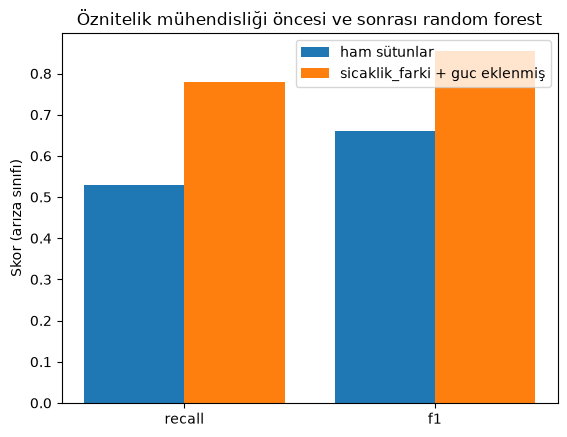

In [20]:
# 26. öznitelik mühendisliği öncesi ve sonrası karşılaştırma grafiği
metrikler = ["recall", "f1"]
onceki_skorlar = [recall_score(y_test, y_pred_forest), f1_score(y_test, y_pred_forest)]
yeni_skorlar = [recall_score(y_test_fe, y_pred_forest_fe), f1_score(y_test_fe, y_pred_forest_fe)]

x_konum = np.arange(len(metrikler))

plt.figure()
plt.bar(x_konum - 0.2, onceki_skorlar, width=0.4, label="ham sütunlar")
plt.bar(x_konum + 0.2, yeni_skorlar, width=0.4, label="sicaklik_farki + guc eklenmiş")
plt.xticks(x_konum, metrikler)
plt.ylabel("Skor (arıza sınıfı)")
plt.title("Öznitelik mühendisliği öncesi ve sonrası random forest")
plt.legend()
plt.savefig("grafikler/fe_oncesi_sonrasi.png", dpi=150, bbox_inches="tight")
plt.show()

Yeni değişkenler önem sıralamasında nereye oturdu diye tekrar baktım.

In [21]:
# 27. yeni modelin feature importance sıralaması
feature_importances_fe = sorted(zip(forest_fe.feature_importances_, ozellik_isimleri_fe), reverse=True)

for importance, feature_name in feature_importances_fe:
    print(f"{feature_name}: {importance}")

guc: 0.24486249263442172
Rotational speed [rpm]: 0.1906329787650439
Torque [Nm]: 0.1862076195700444
Tool wear [min]: 0.1360527163048562
sicaklik_farki: 0.12494884697541789
Air temperature [K]: 0.050163259436996864
Process temperature [K]: 0.045470095435093255
Type_L: 0.013126161565624598
Type_M: 0.008535829312501197


## Stratified k-fold ile çapraz doğrulama

Buraya kadar bütün skorlar tek bir train/test bölünmesinden geldi. Şanslı ya da şanssız bir bölünmeye denk gelmiş olabilirim. Hocanın cross validation dersindeki StratifiedKFold ile ana modelleri 5 parçada değerlendiriyorum. Stratified olması önemli: her fold'da %3.4'lük arıza oranı korunuyor, düz KFold'da şanssız bir fold'a çok az arıza düşebilirdi. Metrik olarak da accuracy değil f1 kullanıyorum.

In [22]:
# 28. stratified k-fold ile çapraz doğrulama (scoring f1, arıza sınıfı)
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# lojistik regresyon için ölçekleme her fold içinde ayrı yapılsın diye pipeline kullandım
log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_reg_f1 = cross_val_score(log_reg_pipeline, X_fe, y_fe, cv=stratified_kfold, scoring="f1")
tree_f1 = cross_val_score(DecisionTreeClassifier(max_depth=5, random_state=42), X_fe, y_fe, cv=stratified_kfold, scoring="f1")
forest_f1 = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X_fe, y_fe, cv=stratified_kfold, scoring="f1")

print(f"lojistik regresyon (balanced) f1: {log_reg_f1}")
print(np.mean(log_reg_f1))
print(np.std(log_reg_f1))

print(f"karar ağacı f1: {tree_f1}")
print(np.mean(tree_f1))
print(np.std(tree_f1))

print(f"random forest f1: {forest_f1}")
print(np.mean(forest_f1))
print(np.std(forest_f1))

lojistik regresyon (balanced) f1: [0.27363184 0.26865672 0.26976744 0.28850856 0.29177719]
0.27846834897210415
0.009729303374147505
karar ağacı f1: [0.75925926 0.78991597 0.73394495 0.7394958  0.71317829]
0.7471588545334451
0.02593298462646983
random forest f1: [0.84745763 0.85245902 0.79646018 0.848      0.77586207]
0.8240477778937508
0.031660280245516766


## Grid search ile hiperparametre araması

Random forest'ın n_estimators=100 ve max_depth ayarlarını şimdiye kadar elle seçtim, daha doğrusu hocanın derste kullandığı değerleri aldım. GridSearchCV verdiğim ızgaradaki bütün kombinasyonları çapraz doğrulamayla deneyip en iyisini söylüyor. İtiraf: grid search'ün özellik seçimi yaptığını sanıyordum ilk duyduğumda, halbuki özellik seçmiyor, hiperparametre seçiyor. Izgarayı küçük tuttum, 12 kombinasyon zaten 60 model eğitimi demek.

In [23]:
# 29. grid search ile random forest hiperparametre araması
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=stratified_kfold,
    scoring="f1",
    n_jobs=-1
)
grid_search.fit(X_train_fe, y_train_fe)

# 30. en iyi modeli test verisi üzerinden değerlendir
y_pred_grid = grid_search.best_estimator_.predict(X_test_fe)

sonuclar = pd.DataFrame([{
    "model": "Random Forest",
    "yontem": "grid_search",
    "cv en iyi score": round(grid_search.best_score_, 3),
    "test score": round(f1_score(y_test_fe, y_pred_grid), 3),
    "en iyi parametre seti": str(grid_search.best_params_)
}])
print(sonuclar)

print(f"en iyi parametreler: {grid_search.best_params_}")
print(f"test recall: {recall_score(y_test_fe, y_pred_grid)}")

           model       yontem  cv en iyi score  test score  \
0  Random Forest  grid_search             0.84       0.855   

                               en iyi parametre seti  
0  {'class_weight': None, 'max_depth': None, 'n_e...  
en iyi parametreler: {'class_weight': None, 'max_depth': None, 'n_estimators': 200}
test recall: 0.7794117647058824


## XGBoost denemesi

Bootcamp'e paralel Andrew Ng'nin Machine Learning kursunu da takip ediyorum, orada gradient boosting anlatılırken XGBoost geçmişti. Kendi verimde denemek istedim. İlk fit denemesinde hata aldım: XGBoost sütun adlarında köşeli parantez kabul etmiyor, "Air temperature [K]" gibi adları temizlemek gerekti. Dengesizlik için de class_weight yerine XGBoost'un scale_pos_weight parametresi var, arızasız/arızalı oranını veriyorsun.

In [24]:
# 31. xgboost sütun adlarındaki köşeli parantezleri kabul etmiyor, adları temizle
X_train_xgb = X_train_fe.rename(columns=lambda isim: isim.replace("[", "").replace("]", ""))
X_test_xgb = X_test_fe.rename(columns=lambda isim: isim.replace("[", "").replace("]", ""))

# 32. xgboost modeli
xgb_clf = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_clf.fit(X_train_xgb, y_train_fe)
y_pred_xgb = xgb_clf.predict(X_test_xgb)

# 33. dengesizlik için scale_pos_weight (yaklaşık arızasız/arızalı oranı)
oran = (y_train_fe == 0).sum() / (y_train_fe == 1).sum()
print(f"arızasız / arızalı oranı: {oran}")

xgb_balanced = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss", scale_pos_weight=oran)
xgb_balanced.fit(X_train_xgb, y_train_fe)
y_pred_xgb_balanced = xgb_balanced.predict(X_test_xgb)

# 34. random forest ile karşılaştırma (arıza sınıfı)
print(f"Random forest (grid search): recall: {recall_score(y_test_fe, y_pred_grid)} --- f1: {f1_score(y_test_fe, y_pred_grid)}")
print(f"XGBoost: recall: {recall_score(y_test_fe, y_pred_xgb)} --- f1: {f1_score(y_test_fe, y_pred_xgb)}")
print(f"XGBoost (scale_pos_weight): recall: {recall_score(y_test_fe, y_pred_xgb_balanced)} --- f1: {f1_score(y_test_fe, y_pred_xgb_balanced)}")

arızasız / arızalı oranı: 28.52029520295203


Random forest (grid search): recall: 0.7794117647058824 --- f1: 0.8548387096774194
XGBoost: recall: 0.7647058823529411 --- f1: 0.8253968253968254
XGBoost (scale_pos_weight): recall: 0.8088235294117647 --- f1: 0.8088235294117647


## SHAP ile modelin kararlarını açıklama

Hocanın açıklanabilirlik dersindeki SHAP kısmını kendi modelime uyguluyorum. Küçük bir itiraf: SHAP'ı ilk duyduğumda model eğiten bir yöntem sanmıştım. Değilmiş. Eğitilmiş bir modeli alıp her tahminde hangi değişkenin sonucu hangi yöne ittiğini hesaplıyor. Grid search'ten çıkan random forest'a hocanın TreeExplainer kalıbını uyguladım.

shap değerleri boyutu: (500, 9)


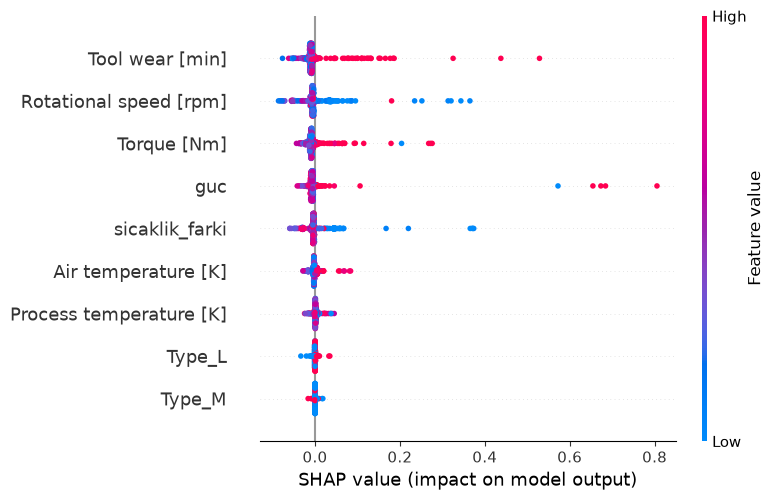

In [25]:
# 35. shap ile özellik katkılarının incelenmesi
# hesap uzun sürdüğü için test setinden ilk 500 örneği kullandım
X_shap = X_test_fe.iloc[:500]

shap_explainer = shap.TreeExplainer(grid_search.best_estimator_)
shap_values = shap_explainer.shap_values(X_shap)

# shap sürümüne göre çıktı list ya da ndarray olabiliyor, arıza sınıfının (1) değerlerini alıyoruz
if isinstance(shap_values, list):
    shap_values_class_1 = shap_values[1]
else:
    shap_values_class_1 = shap_values[:, :, 1]

print(f"shap değerleri boyutu: {shap_values_class_1.shape}")

# 36. summary plot
shap.summary_plot(shap_values_class_1, X_shap, show=False)
plt.savefig("grafikler/shap_ozeti.png", dpi=150, bbox_inches="tight")
plt.show()

## Çıkarımlar

Bu projeden aklımda kalanlar:

- Tork, dönüş hızı ve takım aşınması arızayı en çok haber veren sensörler çıktı, sıcaklıklar onları takip etti.
- Dengesiz veri setinde accuracy tek başına yanıltıcı. Recall ve f1'e bakmadan model iyi mi kötü mü söylenemiyor.
- class_weight="balanced" lojistik regresyonda recall'u ciddi artırdı ama precision düştü, yani daha fazla yanlış alarm. Üretimde hangisinin tercih edileceği duruş maliyeti ile bakım maliyetinin karşılaştırılmasına bağlı.
- TWF, HDF gibi sütunları modele vermek veri sızıntısına yol açıyor. Skor çok iyi çıktığında sevinmeden önce "neden bu kadar iyi" diye sormak gerekiyor.
- Veri setinin dokümantasyonunu okuyup sicaklik_farki ve guc değişkenlerini eklemek, f1'i 0.66'dan 0.85'e taşıdı. Grid search ise elle seçtiğim ayarlardan anlamlı bir fark bulamadı. Alan bilgisi, model ayarı aramaktan daha değerli olabiliyor.
- Tek train/test bölünmesine fazla güvenmemek gerekiyor; stratified k-fold ortalaması ve standart sapması daha sağlam bir resim veriyor.
- XGBoost scale_pos_weight ile en yüksek recall'u verdi ama f1'de random forest'ın gerisinde kaldı.
- SHAP feature importance ile aynı değişkenleri öne çıkardı ama fazlasını da gösterdi: guc değişkeninin hem çok düşük hem çok yüksek değerleri arıza yönüne itiyor, bu PWF tanımıyla birebir uyumlu.
- RNF (rastgele arızalar) gibi sensörlere yansımayan arızaları modelin yakalaması mümkün değil, modelin sınırı bu.